In [1]:
import os
import sys
import yaml
import importlib
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))
import graph
importlib.reload(graph)

from graph import loadPMF, iterGroupedConstructions, graphFullPairPanel

pmfPathTemp = "data/<pair>/pmf-<method>.dat"
diffPathTemp = "data/<pair>/diff-<method>.dat"
ymlPathTemp = "data/<pair>/about.yml"

saveDir = "/Users/yasmene/rc/gbx-graphs-git/figs"

PMF_MODELS = (
    ('GB*',  'gb', 'gbx'),
    ('GB**', 'gb', 'gbxx'),
    ('MM*',  'mm', 'mmx'),
)

def drawResultPanel(ax, pairInfo, model, show_ylabel=True):
    """Draw one resulting PMF; return the model actually displayed."""
    baseKeys = {'gbx': 'gb', 'gbxx': 'gb', 'mmx': 'mm'}
    status = graph._columnStatus(pairInfo, model)
    shownModel = model

    # Match the behavior of your correction grid.
    if model == 'gbxx' and status is not None:
        if graph._columnStatus(pairInfo, 'gbx') is None:
            shownModel = 'gbx'
            status = None

    plt.sca(ax)

    if status is None:
        graph._drawResultPMF(
            ax,
            pairInfo,
            baseKeys[shownModel],
            shownModel,
        )
    else:
        graph._blankPanel(ax, status)

    graph.pubPMF(pairInfo, show_ylabel=show_ylabel)
    return shownModel

In [2]:
def iterGroupedResults(pairInfos):
    byType = {}
    byQprod = {}

    for pairInfo in pairInfos:
        byType.setdefault(
            graph._pairType(pairInfo), []
        ).append(pairInfo)

        qprod = (
            pairInfo['A']['charge']
            * pairInfo['B']['charge']
        )
        byQprod.setdefault(qprod, []).append(pairInfo)

    groups = [
        ('type', name, byType[name])
        for name in (
            'DMA–anything',
            'acetate–anything',
            'ion–ion',
        )
        if name in byType
    ]
    groups += [
        ('qprod', qprod, byQprod[qprod])
        for qprod in sorted(byQprod)
    ]

    for grouping, groupName, groupPairs in groups:
        nRows = len(groupPairs)
        figureHeight = 2.45 if nRows == 1 else 1.65 * nRows + 0.6
        plotTop = 0.76 if nRows == 1 else 0.88

        fig = plt.figure(figsize=(9.2, figureHeight))
        grid = fig.add_gridspec(
            nRows, 3,
            left=0.21, right=0.97,
            top=plotTop, bottom=0.12,
            wspace=0, hspace=0,
        )

        allAxes = []
        sharedX = None

        for rowIndex, pairInfo in enumerate(groupPairs):
            firstAx = fig.add_subplot(
                grid[rowIndex, 0],
                sharex=sharedX,
            )
            if sharedX is None:
                sharedX = firstAx

            rowAxes = [firstAx] + [
                fig.add_subplot(
                    grid[rowIndex, colIndex],
                    sharex=sharedX,
                    sharey=firstAx,
                )
                for colIndex in (1, 2)
            ]
            allAxes.append(rowAxes)

            for colIndex, (title, baseKey, model) in enumerate(PMF_MODELS):
                ax = rowAxes[colIndex]
                drawResultPanel(
                    ax, pairInfo, model,
                    show_ylabel=(colIndex == 0),
                )

                if rowIndex == 0:
                    ax.set_title(
                        title, fontsize=12,
                        fontweight='bold', pad=5,
                    )
                else:
                    ax.set_title('')

            firstAx.set_ylabel(
                r'PMF (kcal mol$^{-1}$)',
                fontsize=8,
                labelpad=6,
            )

            box = firstAx.get_position()
            graph._drawStackedPairName(
                fig, pairInfo, (box.y0 + box.y1) / 2,
            )

        for rowAxes in allAxes[:-1]:
            for ax in rowAxes:
                ax.set_xlabel('')
                ax.tick_params(
                    axis='x', which='both',
                    labelbottom=False,
                )

        for ax in allAxes[-1]:
            ax.set_xlabel(r'$r$ (nm)', fontsize=9)
            ax.tick_params(
                axis='x', which='both',
                labelbottom=True,
            )

        if grouping == 'type':
            heading = f'Resulting PMFs | {groupName}'
        else:
            heading = (
                'Resulting PMFs | '
                f'qA qB = {graph._formatQprod(groupName)}'
            )

        fig.suptitle(
            heading, fontsize=13,
            fontweight='bold', y=0.98,
        )

        yield grouping, groupName, fig, allAxes

Loaded: data/ace-ace/pmf-gb.dat
Loaded: data/ace-ace/pmf-mm.dat
Loaded: data/ace-ace/diff-gbx.dat
Loaded: data/ace-ca/pmf-gb.dat
Loaded: data/ace-ca/pmf-mm.dat
Loaded: data/ace-ca/pmf-dft.dat
Loaded: data/ace-ca/diff-gbx.dat
Loaded: data/ace-ca/diff-gbxx.dat
Loaded: data/ace-ca/diff-mmx.dat
Loaded: data/ace-cl/pmf-gb.dat
Loaded: data/ace-cl/pmf-mm.dat
Loaded: data/ace-cl/diff-gbx.dat
Loaded: data/ace-dma/pmf-gb.dat
Loaded: data/ace-dma/pmf-mm.dat
Loaded: data/ace-dma/diff-gbx.dat
Loaded: data/ace-na/pmf-gb.dat
Loaded: data/ace-na/pmf-mm.dat
Loaded: data/ace-na/pmf-dft.dat
Loaded: data/ace-na/diff-gbx.dat
Loaded: data/ace-na/diff-gbxx.dat
Loaded: data/ace-na/diff-mmx.dat
Loaded: data/ca-ca/pmf-gb.dat
Loaded: data/ca-ca/pmf-mm.dat
Loaded: data/ca-ca/pmf-dft.dat
Loaded: data/ca-ca/diff-gbx.dat
Loaded: data/ca-ca/diff-gbxx.dat
Loaded: data/ca-ca/diff-mmx.dat
Loaded: data/ca-cl/pmf-gb.dat
Loaded: data/ca-cl/pmf-mm.dat
Loaded: data/ca-cl/pmf-dft.dat
Loaded: data/ca-cl/diff-gbx.dat
Loaded: da

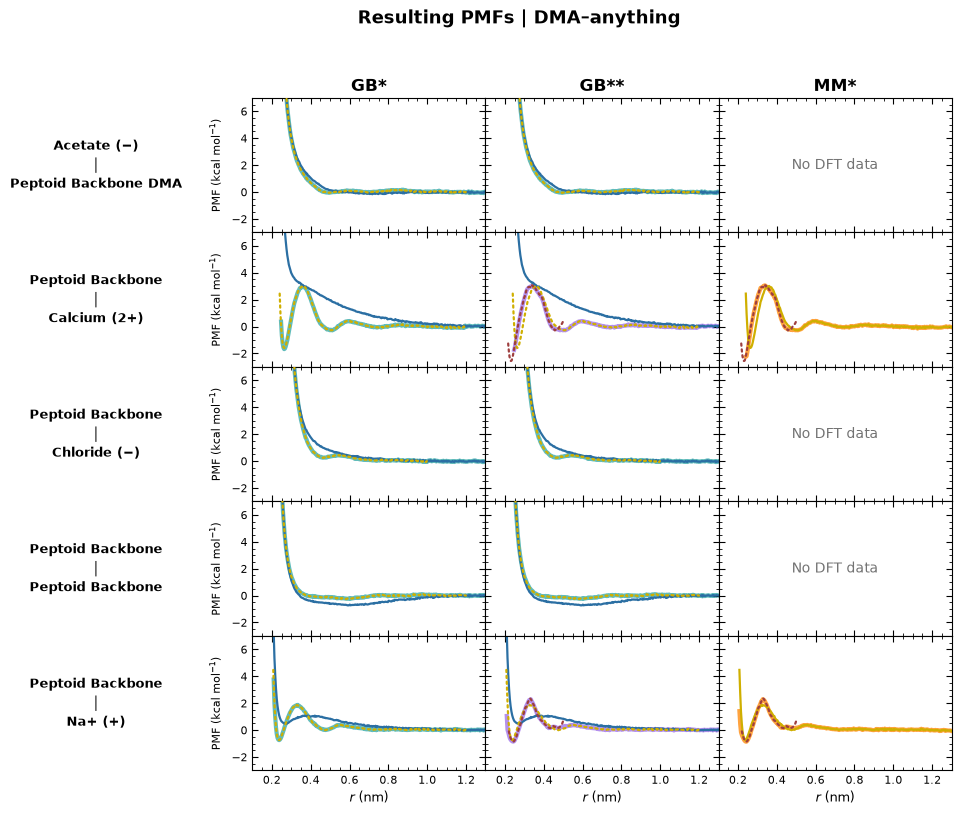

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_type_acetate-anything.pdf


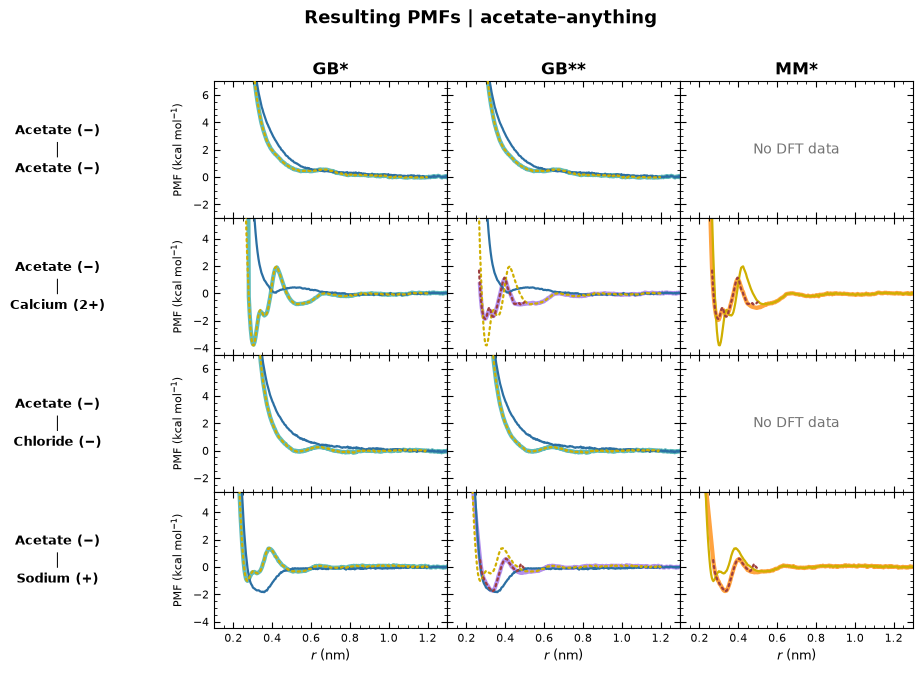

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_type_ion-ion.pdf


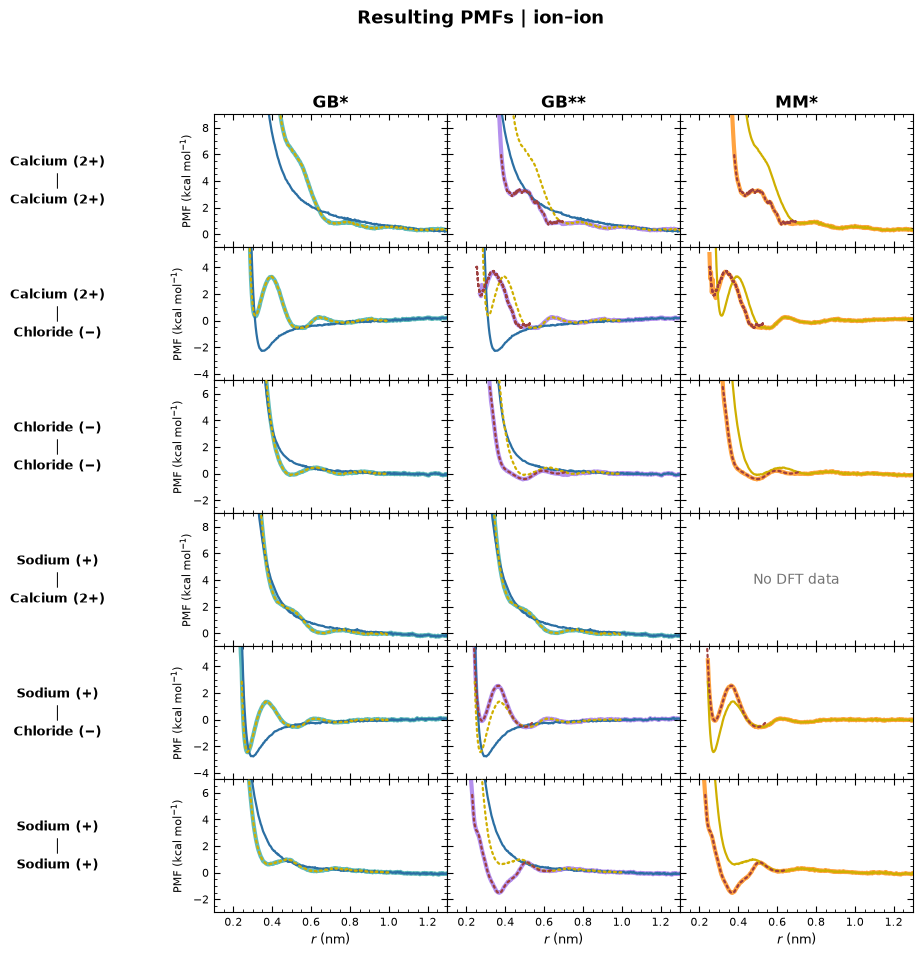

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_-2.pdf


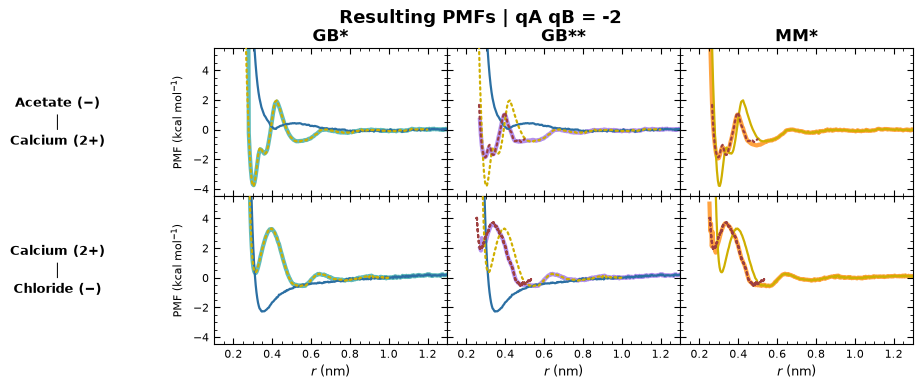

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_-1.pdf


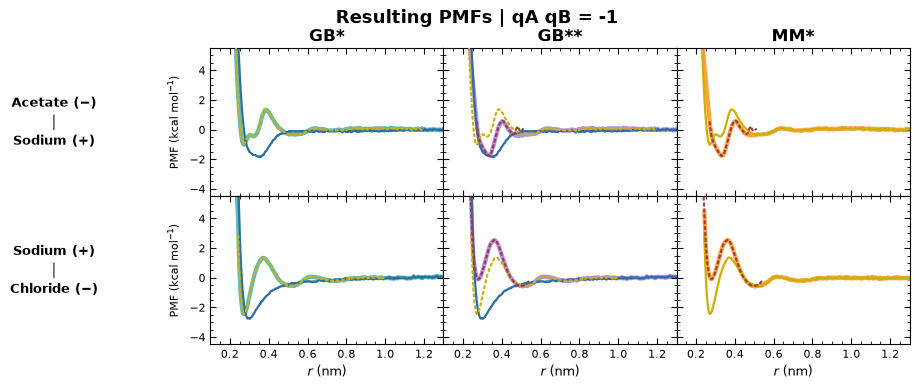

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_0.pdf


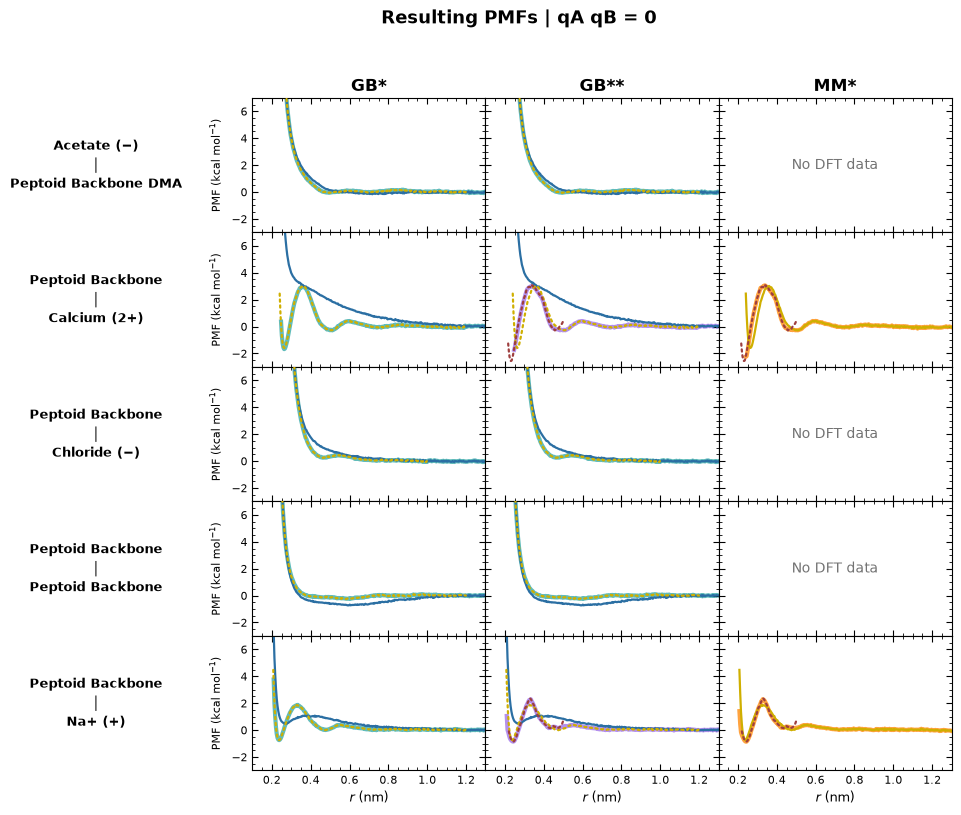

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_1.pdf


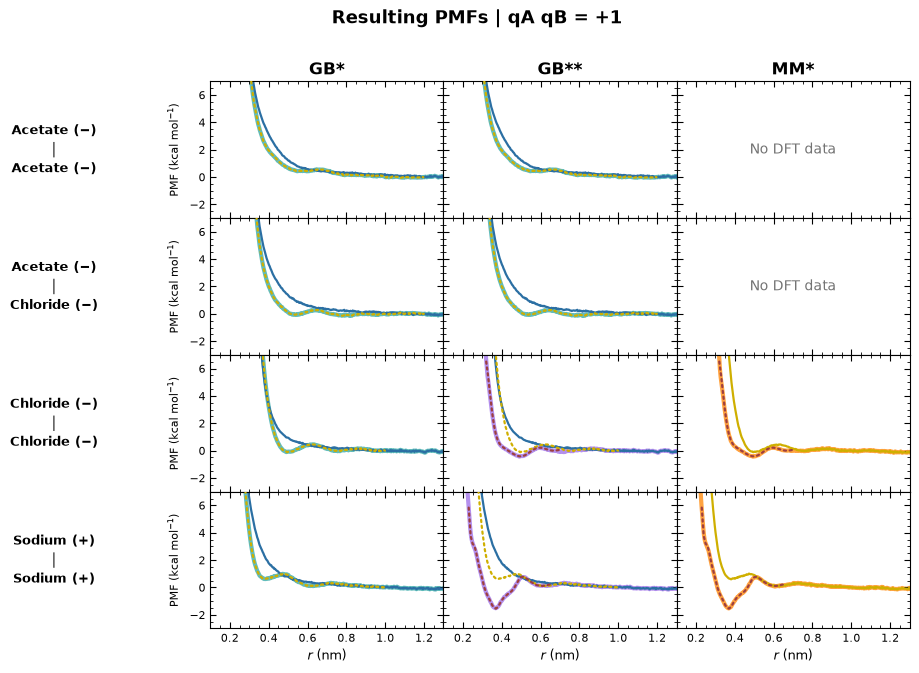

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_2.pdf


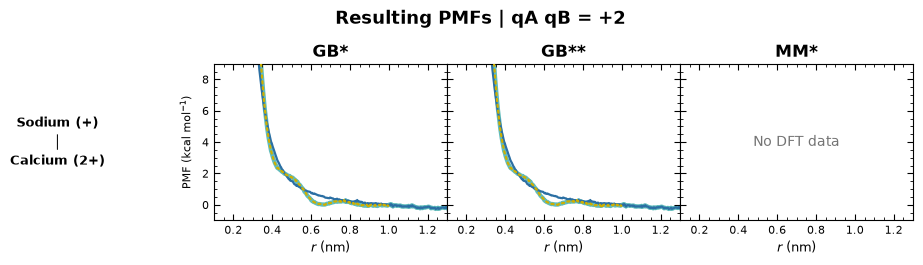

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_qprod_4.pdf


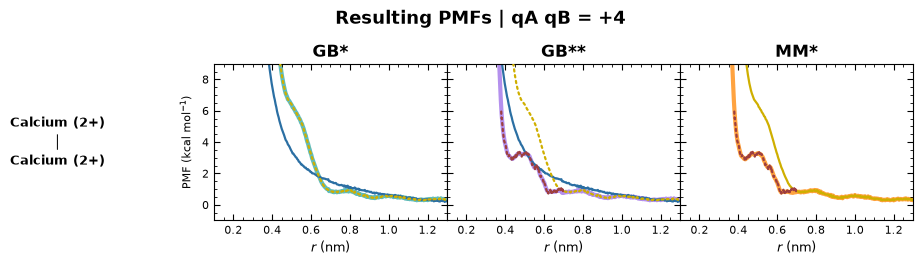

In [3]:
def temp2path(template, pair, method):
    return (
        template
        .replace('<pair>', pair)
        .replace('<method>', method)
    )

pairList = sorted(
    name for name in os.listdir('data')
    if "-" in name and os.path.isdir(os.path.join('data', name))
)

pairInfos = []

for pairName in pairList:
    ymlPath = temp2path(ymlPathTemp, pairName, '')

    if not os.path.isfile(ymlPath):
        print(f"Skipping {pairName}: no about.yml")
        continue

    with open(ymlPath) as stream:
        pairInfo = yaml.safe_load(stream)

    # Convert absent method entries to dictionaries.
    for method in ('gb', 'mm', 'dft', 'gbx', 'gbxx', 'mmx'):
        pairInfo[method] = pairInfo.get(method) or {}

    # Load available base/reference PMFs.
    for method in ('gb', 'mm', 'dft'):
        path = temp2path(pmfPathTemp, pairName, method)
        if os.path.isfile(path):
            pairInfo[method]['pmfData'] = loadPMF(path)

    # Load available corrections.
    for method in ('gbx', 'gbxx', 'mmx'):
        path = temp2path(diffPathTemp, pairName, method)
        if os.path.isfile(path) and pairInfo[method]:
            pairInfo[method]['diffData'] = loadPMF(path)

    pairInfos.append(pairInfo)

print(f"\nLoaded {len(pairInfos)} pairs")

for grouping, groupName, fig, axes in iterGroupedResults(pairInfos):
    safeName = (
        str(groupName)
        .replace('–', '-')
        .replace(' ', '_')
    )
    savePath = os.path.join(
        saveDir,
        f'resulting_pmf_{grouping}_{safeName}.pdf',
    )

    fig.savefig(savePath, bbox_inches='tight')
    print(f'Saved {savePath}')
    display(fig)
    plt.close(fig)

In [4]:
def graphResultGrid(pairInfos, layout, model='gbx', rowYlims=None):
    model = model.lower()
    if model not in {'gbx', 'gbxx', 'mmx'}:
        raise ValueError("model must be 'gbx', 'gbxx', or 'mmx'")

    if not layout or not layout[0]:
        raise ValueError('layout must contain at least one pair')

    nRows = len(layout)
    nCols = len(layout[0])

    if any(len(row) != nCols for row in layout):
        raise ValueError('Every layout row must have the same length')
    if rowYlims is not None and len(rowYlims) != nRows:
        raise ValueError('Provide one y-limit range per row')

    def pairKey(names):
        return tuple(sorted(name.strip().lower() for name in names))

    byPair = {}
    for pairInfo in pairInfos:
        key = pairKey((
            pairInfo['A']['abbreviation'],
            pairInfo['B']['abbreviation'],
        ))
        if key in byPair:
            raise ValueError(f'Duplicate pair: {key}')
        byPair[key] = pairInfo

    missing = [
        names for row in layout for names in row
        if pairKey(names) not in byPair
    ]
    if missing:
        raise ValueError(f'Pairs absent from pairInfos: {missing}')

    nameLabels = {
        'ace': 'Acetate',
        'dma': 'DMA',
        'ca': 'Ca',
        'cl': 'Cl',
        'na': 'Na',
    }

    fig, axes = plt.subplots(
        nRows, nCols,
        figsize=(3.5 * nCols, 2.4 * nRows),
        sharex=True,
        sharey='row',
        squeeze=False,
        gridspec_kw={'wspace': 0, 'hspace': 0},
    )
    fig.subplots_adjust(
        left=0.10, right=0.98,
        bottom=0.12, top=0.97,
    )

    for rowIndex, row in enumerate(layout):
        for colIndex, names in enumerate(row):
            pairInfo = byPair[pairKey(names)]
            ax = axes[rowIndex, colIndex]

            drawResultPanel(
                ax, pairInfo, model,
                show_ylabel=(colIndex == 0),
            )

            if rowYlims is not None:
                ax.set_ylim(*rowYlims[rowIndex])

            displayNames = [
                nameLabels.get(name.lower(), name)
                for name in names
            ]
            ax.text(
                0.97, 0.96,
                '–'.join(displayNames),
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.75,
                    pad=1.5,
                ),
                zorder=21,
            )

            if colIndex == 0:
                ax.set_ylabel(
                    r'PMF (kcal mol$^{-1}$)',
                    fontsize=9, labelpad=6,
                )
            else:
                ax.set_ylabel('')

            if rowIndex == nRows - 1:
                ax.set_xlabel(r'$r$ (nm)', fontsize=9)
            else:
                ax.set_xlabel('')
                ax.tick_params(
                    axis='x', which='both',
                    labelbottom=False,
                )

    return fig, axes

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_grid_gbx.pdf


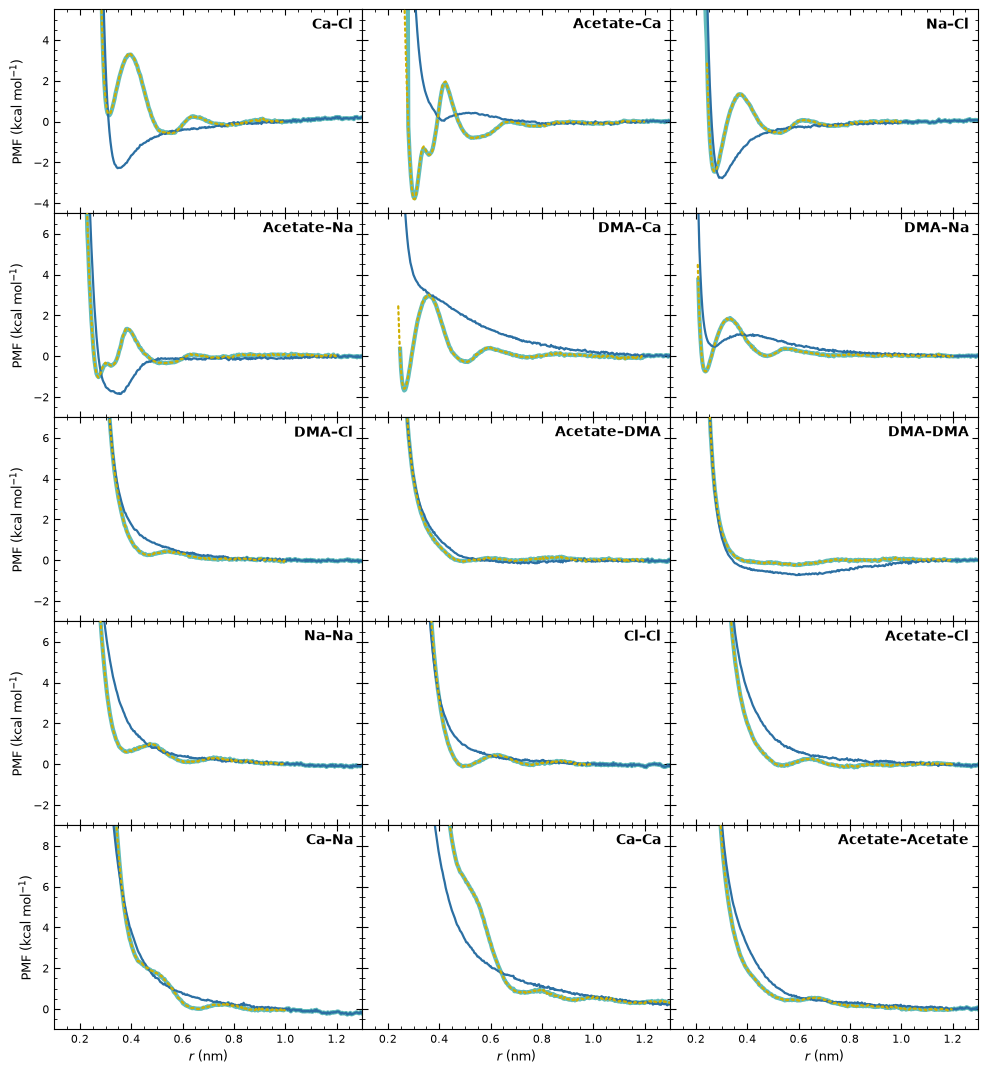

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_grid_gbxx.pdf


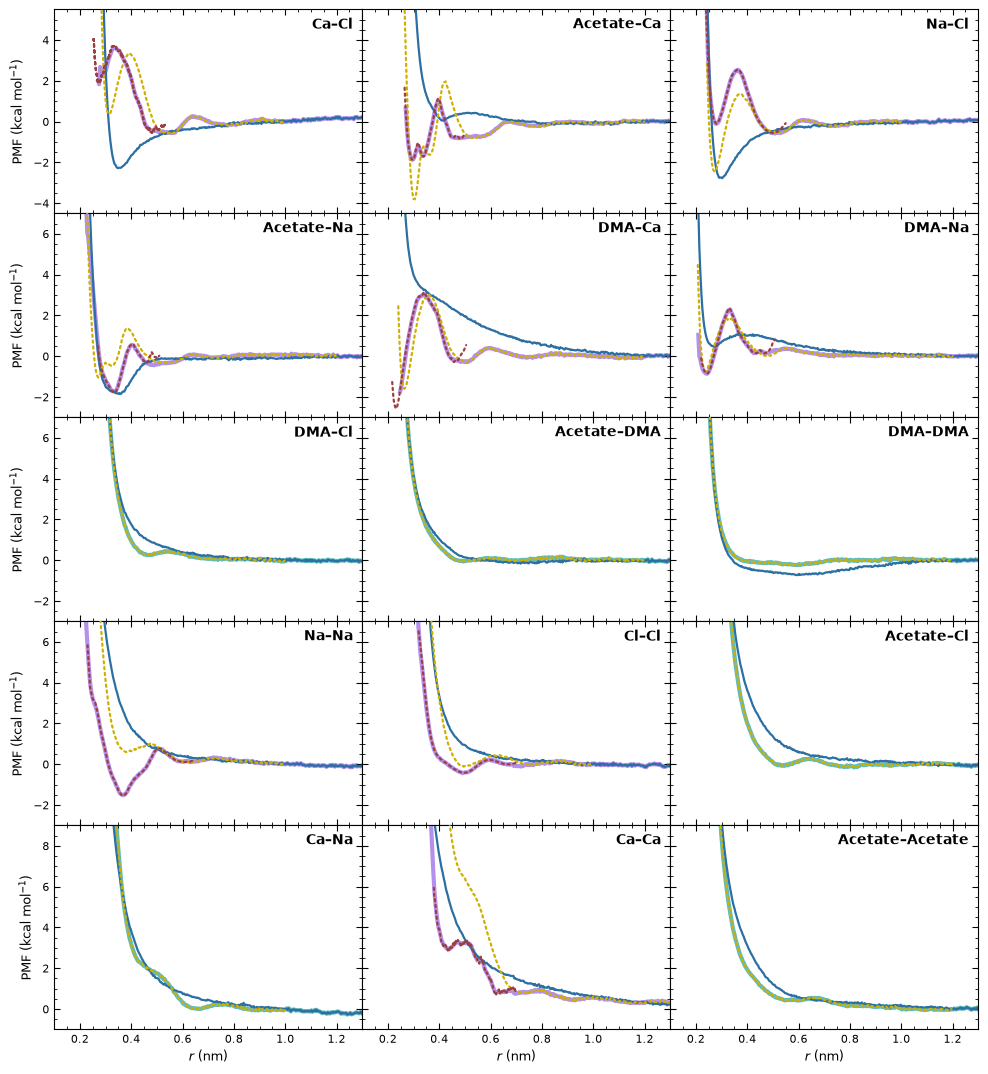

Saved /Users/yasmene/rc/gbx-graphs-git/figs/resulting_pmf_grid_mmx.pdf


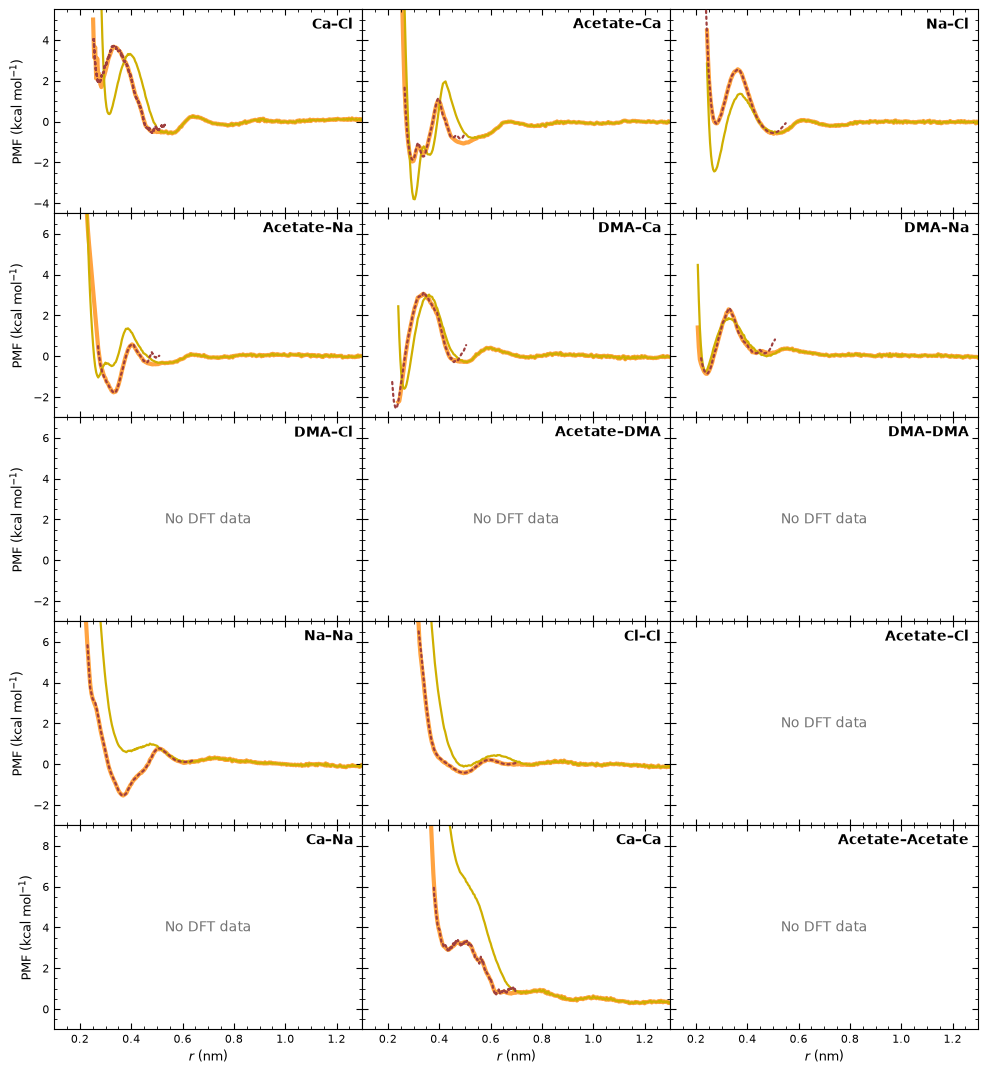

In [5]:
layout = [
    [('ca', 'cl'),  ('ace', 'ca'),  ('na', 'cl')],
    [('ace', 'na'), ('dma', 'ca'),  ('dma', 'na')],
    [('dma', 'cl'), ('ace', 'dma'), ('dma', 'dma')],
    [('na', 'na'),  ('cl', 'cl'),   ('ace', 'cl')],
    [('ca', 'na'),  ('ca', 'ca'),   ('ace', 'ace')],
]

rowYlims = [
    (-4.5, 5.5),
    (-3, 7),
    (-3, 7),
    (-3, 7),
    (-1, 9),
]

for model in ('gbx', 'gbxx', 'mmx'):
    fig, axes = graphResultGrid(
        pairInfos,
        layout,
        model=model,
        rowYlims=rowYlims,
    )

    savePath = os.path.join(
        saveDir,
        f'resulting_pmf_grid_{model}.pdf',
    )
    fig.savefig(savePath, bbox_inches='tight')
    print(f'Saved {savePath}')

    display(fig)
    plt.close(fig)